In [1]:
import pandas as pd
from pathlib import Path
import plotly.graph_objects as go
import numpy as np

snp = pd.read_csv(Path.cwd().parent / "data" / "OHCL" / "investing_dot_com_transformed" / "CSPX ETF Stock Price History.csv")
china = pd.read_csv(Path.cwd().parent / "data" / "OHCL" / "investing_dot_com_transformed" / "CNYA ETF Stock Price History.csv")
em = pd.read_csv(Path.cwd().parent / "data" / "OHCL" / "investing_dot_com_transformed" / "EIMI ETF Stock Price History.csv")
gold = pd.read_csv(Path.cwd().parent / "data" / "OHCL" / "investing_dot_com_transformed" / "XAD5 ETF Stock Price History.csv")
india = pd.read_csv(Path.cwd().parent / "data" / "OHCL" / "investing_dot_com_transformed" / "INR ETF Stock Price History.csv")
mscieurope = pd.read_csv(Path.cwd().parent / "data" / "OHCL" / "investing_dot_com_transformed" / "XMEU ETF Stock Price History.csv")
smallcapeurope = pd.read_csv(Path.cwd().parent / "data" / "OHCL" / "investing_dot_com_transformed" / "SXRJ ETF Stock Price History.csv")
ussmallcap = pd.read_csv(Path.cwd().parent / "data" / "OHCL" / "investing_dot_com_transformed" / "CUSS ETF Stock Price History.csv")
silver = pd.read_csv(Path.cwd().parent / "data" / "OHCL" / "investing_dot_com_transformed" / "SSLN ETF Stock Price History.csv")

dfs = [snp, china, em, gold, india, mscieurope, smallcapeurope, ussmallcap, silver]
labels = ["SNP", "China", "EM", "Gold", "India", "MSCI-Europe", "SmallCapEurope", "USSmallCap", "Silver"]
date_sets = [set(df["Date"]) for df in dfs]

# Find the intersection of all date sets
common_dates = set.intersection(*date_sets)
# Filter each DataFrame to include only common dates
dfs = [df[df["Date"].isin(common_dates)] for df in dfs]
print([len(x) for x in dfs])

N = len(dfs)
T = len(dfs[0]) - 1

returns_all = np.empty((T, N))
for i, df in enumerate(dfs):
    returns_all[:, i] = df["Price"].pct_change().values[1:]

cov = np.cov(returns_all, rowvar=False)
eigvals, eigvectors = np.linalg.eig(cov)
print('eigvals:')
print(eigvals)

[2414, 2414, 2414, 2414, 2414, 2414, 2414, 2414, 2414]
eigvals:
[8.00953385e-04 3.99842024e-04 2.19093617e-04 1.19374200e-04
 5.11578183e-05 1.54907292e-05 1.92703667e-05 3.55808752e-05
 3.29416879e-05]


In [2]:
# Sort eigenvalues and eigenvectors in descending order
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvectors = eigvectors[:, idx]

In [3]:
total_variance = np.sum(eigvals)
explained_variance = eigvals / total_variance
print("Explained variance by each PC:")
for i, (val, exp_var) in enumerate(zip(eigvals, explained_variance)):
    print(f"PC {i+1}: Eigenvalue = {val:.6f}, Explained Variance = {exp_var:.2%}")

Explained variance by each PC:
PC 1: Eigenvalue = 0.000801, Explained Variance = 47.29%
PC 2: Eigenvalue = 0.000400, Explained Variance = 23.61%
PC 3: Eigenvalue = 0.000219, Explained Variance = 12.94%
PC 4: Eigenvalue = 0.000119, Explained Variance = 7.05%
PC 5: Eigenvalue = 0.000051, Explained Variance = 3.02%
PC 6: Eigenvalue = 0.000036, Explained Variance = 2.10%
PC 7: Eigenvalue = 0.000033, Explained Variance = 1.94%
PC 8: Eigenvalue = 0.000019, Explained Variance = 1.14%
PC 9: Eigenvalue = 0.000015, Explained Variance = 0.91%


In [4]:
# Print loadings for the first 3 PCs
for i in range(3):
    print(f"\nLoadings for PC {i+1}:")
    for j, label in enumerate(labels):
        print(f"{label}: {eigvectors[j, i]:.4f}")


Loadings for PC 1:
SNP: 0.3314
China: 0.4251
EM: 0.4239
Gold: 0.0375
India: 0.3466
MSCI-Europe: 0.2922
SmallCapEurope: 0.3369
USSmallCap: 0.4080
Silver: 0.2071

Loadings for PC 2:
SNP: 0.1015
China: -0.0149
EM: 0.0432
Gold: -0.3600
India: 0.1393
MSCI-Europe: 0.0639
SmallCapEurope: 0.1121
USSmallCap: 0.1208
Silver: -0.8986

Loadings for PC 3:
SNP: 0.1830
China: -0.8685
EM: -0.0542
Gold: 0.0441
India: 0.2322
MSCI-Europe: 0.1627
SmallCapEurope: 0.1910
USSmallCap: 0.2744
Silver: 0.1231


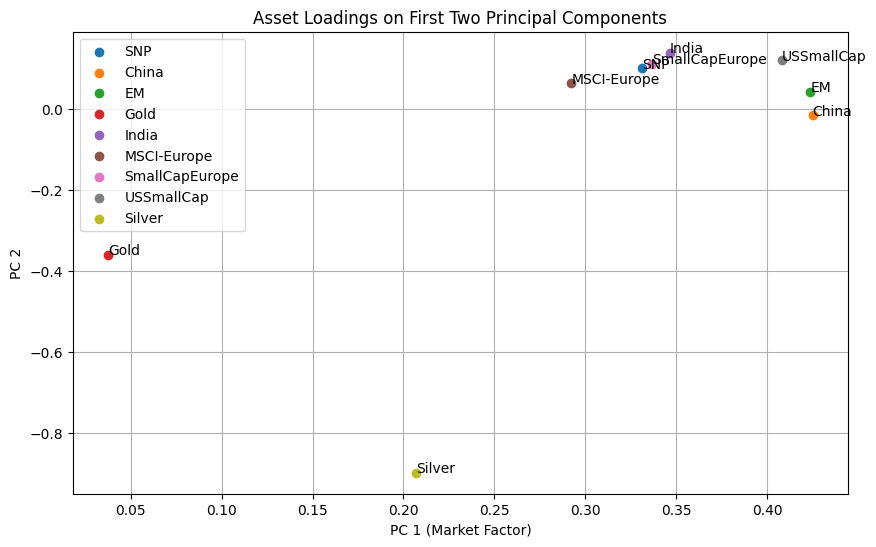

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for i, label in enumerate(labels):
    plt.scatter(eigvectors[i, 0], eigvectors[i, 1], label=label)
    plt.text(eigvectors[i, 0], eigvectors[i, 1], label)
plt.xlabel("PC 1 (Market Factor)")
plt.ylabel("PC 2")
plt.title("Asset Loadings on First Two Principal Components")
plt.grid()
plt.legend()
plt.show()

In [6]:
# Reconstruct covariance matrix using top 3 PCs
n_top_pcs = 3
reconstructed_cov = np.zeros_like(cov)
for i in range(n_top_pcs):
    reconstructed_cov += eigvals[i] * np.outer(eigvectors[:, i], eigvectors[:, i])

print("Reconstructed covariance matrix (using top 3 PCs):")
print(reconstructed_cov)

Reconstructed covariance matrix (using top 3 PCs):
[[ 9.94478369e-05  7.74197338e-05  1.12101063e-04 -2.87729472e-06
   1.06967981e-04  8.66988779e-05  1.01651818e-04  1.24222746e-04
   2.34430282e-05]
 [ 7.74197338e-05  3.10063689e-04  1.54372039e-04  6.52585040e-06
   7.29841021e-05  6.81515929e-05  7.76885574e-05  8.59717489e-05
   5.24418411e-05]
 [ 1.12101063e-04  1.54372039e-04  1.45286676e-04  6.00428358e-06
   1.17302335e-04  9.83817150e-05  1.14045081e-04  1.37340358e-04
   5.33357862e-05]
 [-2.87729472e-06  6.52585040e-06  6.00428358e-06  5.33649084e-05
  -7.38688016e-06  1.16718609e-06 -4.15759930e-06 -2.46497392e-06
   1.36744335e-04]
 [ 1.06967981e-04  7.29841021e-05  1.17302335e-04 -7.38688016e-06
   1.15772371e-04  9.29568627e-05  1.09484736e-04  1.33946829e-04
   1.36989468e-05]
 [ 8.66988779e-05  6.81515929e-05  9.83817150e-05  1.16718609e-06
   9.29568627e-05  7.58378754e-05  8.85361302e-05  1.08373305e-04
   2.99201809e-05]
 [ 1.01651818e-04  7.76885574e-05  1.140450

In [7]:
# Equal weights portfolio
weights = np.ones(N) / N

# Total portfolio variance
total_variance = weights.T @ cov @ weights

# Portfolio variance explained by top PCs
reconstructed_variance = weights.T @ reconstructed_cov @ weights

print(f"Total portfolio variance: {total_variance:.6f}")
print(f"Variance explained by top {n_top_pcs} PCs: {reconstructed_variance:.6f}")
print(f"Proportion of variance explained: {reconstructed_variance / total_variance:.2%}")

Total portfolio variance: 0.000081
Variance explained by top 3 PCs: 0.000081
Proportion of variance explained: 99.68%
